**Setup**

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
from src import config
from src.data import loader, preprocessing
from src.models.cnn import build_custom_cnn
from src.training.train import train_model
from src.evaluation import metrics, evaluation
from src.evaluation.confusion_matrix import plot_confusion_matrix

train_df, val_df, test_df = loader.create_splits()
train_ds = preprocessing.make_dataset(train_df, training=True)
val_ds = preprocessing.make_dataset(val_df)
test_ds = preprocessing.make_dataset(test_df)

**One-epoch test**

In [2]:
model = build_custom_cnn()
history_df, seconds = train_model(model, train_ds, val_ds, "custom_cnn", epochs=1)
print(f"1 epoch took {seconds/60:.1f} minutes")

D:\project\brain-tumor-detection\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


132/132 ━━━━━━━━━━━━━━━━━━━━ 290s 2s/step - accuracy: 0.4084 - loss: 1.2186 - val_accuracy: 0.4146 - val_loss: 1.1396 - learning_rate: 0.0010
1 epoch took 4.8 minutes


**Full training**

Epoch 1/20


D:\project\brain-tumor-detection\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


132/132 ━━━━━━━━━━━━━━━━━━━━ 288s 2s/step - accuracy: 0.4001 - loss: 1.2311 - val_accuracy: 0.3520 - val_loss: 1.3348 - learning_rate: 0.0010
Epoch 2/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 330s 2s/step - accuracy: 0.5458 - loss: 1.0133 - val_accuracy: 0.5740 - val_loss: 0.9770 - learning_rate: 0.0010
Epoch 3/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 290s 2s/step - accuracy: 0.5866 - loss: 0.9582 - val_accuracy: 0.4772 - val_loss: 1.1761 - learning_rate: 0.0010
Epoch 4/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 318s 2s/step - accuracy: 0.6075 - loss: 0.9271 - val_accuracy: 0.3975 - val_loss: 1.4032 - learning_rate: 0.0010
Epoch 5/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 286s 2s/step - accuracy: 0.6388 - loss: 0.8796 - val_accuracy: 0.4772 - val_loss: 1.2158 - learning_rate: 5.0000e-04
Epoch 6/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 334s 2s/step - accuracy: 0.6452 - loss: 0.8590 - val_accuracy: 0.5047 - val_loss: 1.1955 - learning_rate: 5.0000e-04
Epoch 7/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 325s 2s/step - accuracy: 0.6673 - loss: 0.833

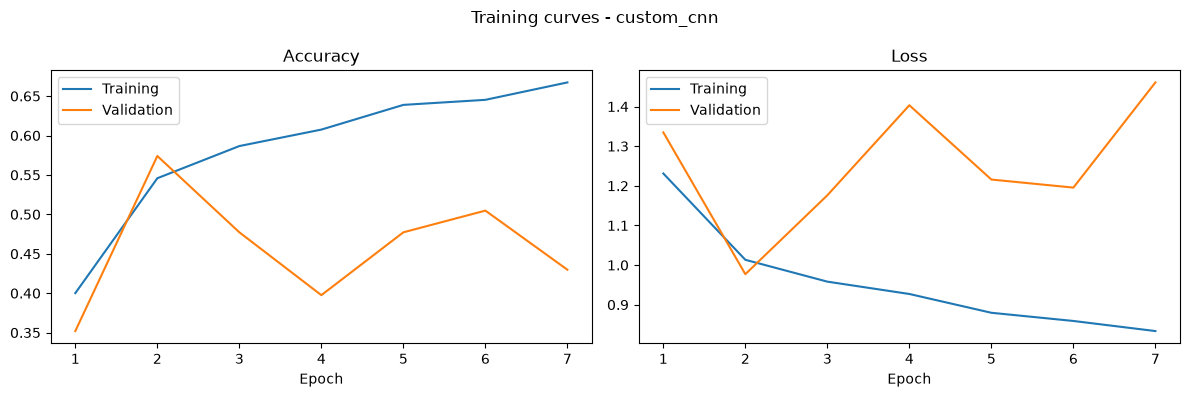

In [3]:
model = build_custom_cnn()      # fresh, untrained model
history_df, seconds = train_model(model, train_ds, val_ds, "custom_cnn")
print(f"Training took {seconds/60:.1f} minutes, {len(history_df)} epochs")
evaluation.plot_training_curves(history_df, "custom_cnn")

**Evaluation**

Validation: {'accuracy': 0.574, 'precision_macro': 0.578, 'recall_macro': 0.575, 'f1_macro': 0.536, 'roc_auc_ovr': 0.837}
Test:       {'accuracy': 0.565, 'precision_macro': 0.585, 'recall_macro': 0.565, 'f1_macro': 0.513, 'roc_auc_ovr': 0.808}
              precision    recall  f1-score   support

      glioma      0.607     0.453     0.519       400
  meningioma      0.616     0.113     0.190       400
     notumor      0.629     0.873     0.731       400
   pituitary      0.488     0.823     0.613       400

    accuracy                          0.565      1600
   macro avg      0.585     0.565     0.513      1600
weighted avg      0.585     0.565     0.513      1600



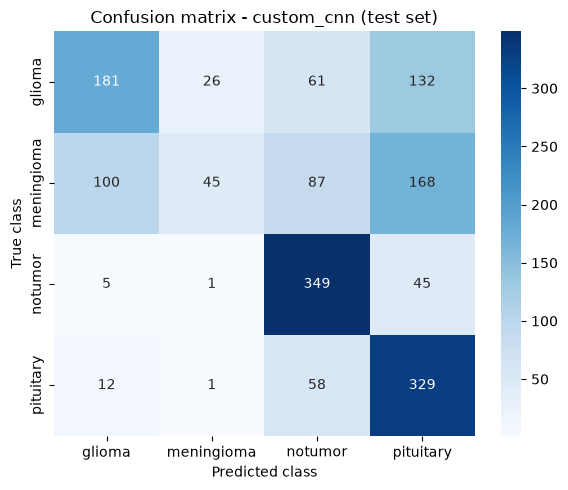

{'model': 'custom_cnn',
 'parameters': 110276,
 'training_time_seconds': 2192.6,
 'epochs_run': 7,
 'best_epoch': 2,
 'validation': {'accuracy': 0.5740037950664136,
  'precision_macro': 0.5783771508707897,
  'recall_macro': 0.5748789126783005,
  'f1_macro': 0.5359942372657118,
  'roc_auc_ovr': 0.836516647041466},
 'test': {'accuracy': 0.565,
  'precision_macro': 0.5851950747817506,
  'recall_macro': 0.565,
  'f1_macro': 0.5131131194748362,
  'roc_auc_ovr': 0.8081869791666667}}

In [4]:
y_val, pred_val, prob_val = metrics.predict_dataset(model, val_ds)
y_test, pred_test, prob_test = metrics.predict_dataset(model, test_ds)

val_metrics = metrics.compute_metrics(y_val, pred_val, prob_val)
test_metrics = metrics.compute_metrics(y_test, pred_test, prob_test)
print("Validation:", {k: round(v, 3) for k, v in val_metrics.items()})
print("Test:      ", {k: round(v, 3) for k, v in test_metrics.items()})
print(metrics.get_classification_report(y_test, pred_test))
plot_confusion_matrix(y_test, pred_test, "custom_cnn")

evaluation.save_results("custom_cnn", val_metrics, test_metrics, seconds,
                        history_df, model.count_params())

In [6]:
check = test_df.copy()
check["correct"] = (y_test == pred_test)
check["is_512"] = (check["width"] == 512) & (check["height"] == 512)
print(check.groupby("is_512")["correct"].agg(["mean", "count"]).round(3))
print()
print(check.groupby(["class", "is_512"])["correct"].agg(["mean", "count"]).round(3))

         mean  count
is_512              
False   0.592    598
True    0.549   1002

                    mean  count
class      is_512              
glioma     False   0.013     76
           True    0.556    324
meningioma False   0.000    117
           True    0.159    283
notumor    False   0.872    397
           True    1.000      3
pituitary  False   0.875      8
           True    0.821    392
